# JEKOVA

In [159]:
# IMPORTS ###########################################

import importlib
import warnings
warnings.filterwarnings("ignore")

#####################################################

import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

from pxg import plot
importlib.reload(plot)

from pxg import Stop
from pxg import FS, MS
from pxg import EXG, Rids, Record

from IPython.display import Markdown, display

%config InlineBackend.figure_format = "retina"

In [160]:
# Visualization

def PlotPage(
    rec: Record, 
    page = 0, 
    offset = 0,
    marker = False,
    include = []
):
    res = plot.Page(
        rec, 
        page, 
        offset,

        SENSOR = False,
        SIGNAL = True,
        DECTOR = False,
        EXTEND = 'JEKOVA',

        # LOW = -700,
        ZEROS = [0],

        # label = "BPM",
        angle = 0,

        rrqs  = False, 
        qsvl  = False, 
        
        punts = False,  
        trig  = False,
        onoff = False,
        letra = False,

        grid  = False,
        anref = False,
        simple = True,

        # simple = False,
        # marker = marker and page not in include,

        show = False,
    )

    if res:
        PON, POF = plot.Range(rec, page, offset)

        # plot.Signal(rec.Local[PON:POF] / MV, zero=-400, color="tab:blue", format="-", linewidth=0.6)
        # plot.Signal(rec.Cover[PON:POF] / MV, zero=-400, color="tab:orange", format="-", linewidth=0.5)

        # plot.Signal(rec.Maxim[PON:POF] / MV, zero=-400, color="tab:red", format="-", linewidth=0.8)
        # plot.Signal(rec.Minim[PON:POF] / MV, zero=-400, color="tab:red", format="-", linewidth=0.8)

        plot.Signal(rec.Digit[PON:POF] * 90, zero=-700, color="tab:gray", format="-", linewidth=0.5, fill=True, alpha=0.2)
        plot.Signal(rec.Class[PON:POF] * 90, zero=-700, color="tab:red", format="-", linewidth=0.5, fill=True, alpha=0.2)
    pass #if

    plot.Show()

    return res
pass #def


def PlotRecord(rec: Record, page: int | list[int] = -1, off = 0, marker = False, title = ""):
    offset = off*plot.FS
    display(Markdown(f"## {rec.DB.upper()} {rec.RID}\n---"))
    if title:
        display(Markdown(f"```text\n{title}\n```"))
    pass #if
    if isinstance(page, list):
        for p in page:
            PlotPage(rec, p, offset, marker = marker)
        pass #for
    elif page != -1:
        PlotPage(rec, page, offset, marker = marker)
    else:
        for page in range(0, (len(rec.Signal) + plot.CHUNK // 2) // plot.CHUNK, 1):
            PlotPage(rec, page, offset, marker = marker)
        pass #for
    pass #if
    return rec
pass #def

def PlotDatabase(db: str):
    # rids = EXG(db, learn = True, cfm = True, devx = False, wrx = False)
    rids = Rids(db)
    for rid in rids:
        rec = Record(db, rid)
        Process(rec)
        for page in range(0, (len(rec.Signal) + plot.CHUNK // 2) // plot.CHUNK, 1):
            PON, POF = plot.Range(rec, page, 0)
            cc = 0
            for epi in rec.RefEpi:
                if epi.End < PON or epi.Time >= POF: continue
                if epi.Name in ["VT", "VFL", "VF", "WF"]: cc+=1
            pass #for
            if cc == 0: continue
            PlotRecord(rec, page = [page], off = 0, marker = False, title = "")
        pass #for
    pass #for
pass #def

In [161]:
LYN_WIND = 40 // MS

def LynnFilter(x: np.ndarray, w: int = LYN_WIND) -> np.ndarray:
    w -= w % 2

    a = np.array([1, -2, 1])
    b = np.zeros(w + 1)
    b[0] = 1
    b[w // 2] = -2
    b[w] = 1
    g = (len(b) // 2) ** 2
    shift = w // 2 - 1

    y = signal.lfilter(b, a, x) / g # type: ignore
    y = np.roll(y, -shift)
    return y
pass #def


FS_TARGET = 250    # Hz; every JEKOVA constant is defined for a 250 Hz sampling rate
HP_HZ = 1.0        # first-order high-pass cutoff (per stage)
LP_HZ = 30.0       # Butterworth low-pass cutoff
LP_ORDER = 2       # second-order Butterworth, as the paper specifies
NOTCH_HZ = 50.0    # powerline notch centre frequency (Sofia/European mains)
NOTCH_Q = 30.0     # notch quality factor (dimensionless); bandwidth = NOTCH_HZ / Q,
                   # so Q = 30 gives a ~1.7 Hz notch. The paper does not specify Q.

# Jekova band-pass (paper eq. 1) in integer form, carrying a gain of 16 like the
# Lynn filters. Paper equation, scaled by 16 to clear the fractions:
#     8*FS[i] = 14*FS[i-1] - 7*FS[i-2] + (S[i] - S[i-2])/2
#    16*FS[i] = 28*FS[i-1] - 14*FS[i-2] + (S[i] - S[i-2])
# Coefficients are integers; the peak gain at the 14.6 Hz centre is JEK_GAIN.
# Divide by JEK_GAIN to get unity peak gain. The Step 6 counts are all relative
# to a per-window max / mean / MD, so the cascade is unaffected by the scale.
JEK_B = [16, 0, -16]
JEK_A = [16, -28, 14]
JEK_GAIN = 16 // 4

def JakovaFilter(x, prep = True):
    y = np.asarray(x, dtype=float)

    if prep:
        ## High pass filter ###############
        hp_b, hp_a = signal.butter(1, HP_HZ / (0.5 * FS_TARGET), btype="highpass") # type: ignore
        y = signal.lfilter(hp_b, hp_a, y)
        y = signal.lfilter(hp_b, hp_a, y)

        ## Low pass filter ################
        lp_b, lp_a = signal.butter(LP_ORDER, LP_HZ / (0.5 * FS_TARGET), btype="lowpass") # type: ignore
        y = signal.lfilter(lp_b, lp_a, y)
        ###################################

        ## Notch filter ###################
        nt_b, nt_a = signal.iirnotch(NOTCH_HZ, NOTCH_Q, fs=FS_TARGET) # type: ignore
        y = signal.lfilter(nt_b, nt_a, y)
    else:
        y = LynnFilter(y)
    pass #if

    ## Jekova Equation ################
    y = signal.lfilter(JEK_B, JEK_A, y) / JEK_GAIN # type: ignore
    ###################################

    return np.array(y)
pass #def

# calculate Jekova counts in a 1 s segment of the band-pass output (paper step 5-6)
def Counts(seg: np.ndarray) -> tuple[int, int, int]:
    # step 5: the counts are defined on the absolute (rectified) filter output
    abs_fs = np.abs(np.asarray(seg, dtype=float))

    smax  = np.max(abs_fs)
    smean = np.mean(abs_fs)
    md    = np.mean(np.abs(abs_fs - smean))   # mean absolute deviation, not median

    # step 6: number of samples falling in each amplitude band
    c1 = int(np.sum(abs_fs >= smax / 2))                                # 0.5*smax .. smax
    c2 = int(np.sum(abs_fs >= smean))                                   # smean    .. smax
    c3 = int(np.sum((abs_fs >= smean - md) & (abs_fs <= smean + md)))   # smean +- MD

    return c1, c2, c3
pass #def
    

COLUMNS = ["db", "rid", "pon", "pof", "vfb", "c1", "c2", "c3"]

def Process(rec: Record) -> tuple[list[dict], list[dict], list[dict]]:
    rec.Jekova = JakovaFilter(rec.Point, False)

    vfib = np.zeros(len(rec.Point), dtype=int)
    for epi in rec.RefEpi:
        if epi.Name in ["#VT", "VFL", "VF", "WF"]:
            vfib[epi.Time:epi.End+1] = 1
        pass #if
    pass #for
    rec.RefVFB = vfib

    rows = []
    for s in range(len(rec.Point) // FS):
        pon = s * FS
        pof = pon + FS
        seg = vfib[pon:pof]
        vfb = int(np.sum(seg))
        c1, c2, c3 = Counts(rec.Jekova[pon:pof])
        rows.append(dict(db=rec.DB, rid=rec.RID, pon=pon, pof=pof, vfb=vfb, c1=c1, c2=c2, c3=c3))
    pass #for

    row4 = []
    for s in range(len(rows) - 4):
        vfb = sum(rows[s+i]["vfb"] for i in range(4))
        c1  = sum(rows[s+i]["c1"]  for i in range(4))
        c2  = sum(rows[s+i]["c2"]  for i in range(4))
        c3  = sum(rows[s+i]["c3"]  for i in range(4))
        row4.append(dict(db=rec.DB, rid=rec.RID, pon=rows[s]["pon"], pof=rows[s+3]["pof"], vfb=vfb, c1=c1, c2=c2, c3=c3))
    pass #for

    row8 = []
    for s in range(len(rows) - 8):
        vfb = sum(rows[s+i]["vfb"] for i in range(8))
        c1  = sum(rows[s+i]["c1"]  for i in range(8))
        c2  = sum(rows[s+i]["c2"]  for i in range(8))
        c3  = sum(rows[s+i]["c3"]  for i in range(8))
        row8.append(dict(db=rec.DB, rid=rec.RID, pon=rows[s]["pon"], pof=rows[s+7]["pof"], vfb=vfb, c1=c1, c2=c2, c3=c3))
    pass #for

    return rows, row4, row8
pass #def

def ProcessDatabase(db: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = []
    row4 = []
    row8 = []

    rids = Rids(db)
    for rid in rids:
        rec = Record(db, rid)
        rs, r4, r8 = Process(rec)
        rows.extend(rs)
        row4.extend(r4)
        row8.extend(r8)
    pass #for
    dfs = pd.DataFrame(rows, columns=COLUMNS)
    df4 = pd.DataFrame(row4, columns=COLUMNS)
    df8 = pd.DataFrame(row8, columns=COLUMNS)

    # Save to work/vfib/{db}
    dfs.to_csv(f"../work/vfib/{db}_dfs.tsv", index=False, sep="\t")
    df4.to_csv(f"../work/vfib/{db}_df4.tsv", index=False, sep="\t")
    df8.to_csv(f"../work/vfib/{db}_df8.tsv", index=False, sep="\t")

    return dfs, df4, df8
pass #def

In [162]:
# Jekova figure 4 style: observed distributions per class, each normalised to its
# own peak, with the corresponding expected normal curve overlaid.
NONSHOCK_COLOR = "#2a78d6"
SHOCK_COLOR    = "#e34948"

def Ratio(df: pd.DataFrame) -> np.ndarray:
    """Count1*Count2/Count3, guarding the empty Count3 band."""
    c3 = df["c3"].to_numpy(dtype=float)
    return df["c1"].to_numpy(dtype=float) * df["c2"].to_numpy(dtype=float) / np.where(c3 > 0, c3, np.nan)
pass #def

def Auc(neg: np.ndarray, pos: np.ndarray) -> float:
    """Rank-based AUC (Mann-Whitney U), ties handled by average ranks."""
    neg = neg[np.isfinite(neg)]
    pos = pos[np.isfinite(pos)]
    if len(neg) == 0 or len(pos) == 0:
        return float("nan")
    pass #if
    ranks = pd.Series(np.concatenate([neg, pos])).rank().to_numpy()
    return (ranks[len(neg):].sum() - len(pos) * (len(pos) + 1) / 2) / (len(neg) * len(pos))
pass #def

def PlotHistograms(df: pd.DataFrame, frac: float = 0.5, bins: int = 50, title: str = "", xlim: str = "max"):
    """Jekova figure 4: how Count1, Count2 and Count1*Count2/Count3 separate VFIB.

    A window counts as shockable when at least ``frac`` of it overlaps a
    VF/VFL/VT episode, and as non-shockable when it does not overlap one at all.
    The partial overlaps in between are ambiguous and left out.

    ``xlim`` picks the x range: "max" spans 0 to the largest observed value,
    "clip" spans the 0.5-99.5 percentiles so outliers cannot squash the bulk.
    """
    span = int(df["pof"].iloc[0] - df["pon"].iloc[0])
    shock    = df[df["vfb"] >= frac * span]
    nonshock = df[df["vfb"] == 0]

    panels = [
        ("Count1",                 df["c1"].to_numpy(dtype=float), shock["c1"].to_numpy(dtype=float), nonshock["c1"].to_numpy(dtype=float)),
        ("Count2",                 df["c2"].to_numpy(dtype=float), shock["c2"].to_numpy(dtype=float), nonshock["c2"].to_numpy(dtype=float)),
        ("Count1*Count2 / Count3", Ratio(df),                      Ratio(shock),                      Ratio(nonshock)),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, (name, allv, pos, neg) in zip(axes, panels):
        if xlim == "clip":
            lo, hi = np.nanpercentile(allv, [0.5, 99.5])
        else:
            lo, hi = 0.0, float(np.nanmax(allv))
        pass #if
        edges = np.linspace(lo, hi, bins + 1)

        for vals, color, label, hatch in [
            (neg, NONSHOCK_COLOR, "Non-shockable", None),
            (pos, SHOCK_COLOR,    "Shockable",     "///"),
        ]:
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue
            pass #if
            h, _ = np.histogram(vals, bins=edges)
            h = h / h.max() if h.max() else h          # each class normalised to its own peak
            ax.stairs(h, edges, fill=True, alpha=0.35, color=color, hatch=hatch, edgecolor=color, linewidth=0)
            ax.stairs(h, edges, color=color, linewidth=2, label=f"{label} (n={len(vals)})")

            mu, sd = vals.mean(), vals.std()
            if sd > 0:
                xs = np.linspace(lo, hi, 200)
                ax.plot(xs, np.exp(-0.5 * ((xs - mu) / sd) ** 2), ":", color=color, linewidth=1.5)
            pass #if
        pass #for

        ax.set_title(f"{name}   (AUC {Auc(neg, pos):.3f})", fontsize=11)
        ax.set_xlabel(name)
        ax.set_xlim(lo, hi)
        ax.set_ylim(0, 1.1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.15)
    pass #for

    axes[0].set_ylabel("Number of observations (normalised)")
    axes[0].legend(frameon=False, fontsize=9)
    fig.suptitle(title or f"Jekova counts, {span // FS} s windows", fontsize=12)
    fig.tight_layout()
    return fig
pass #def

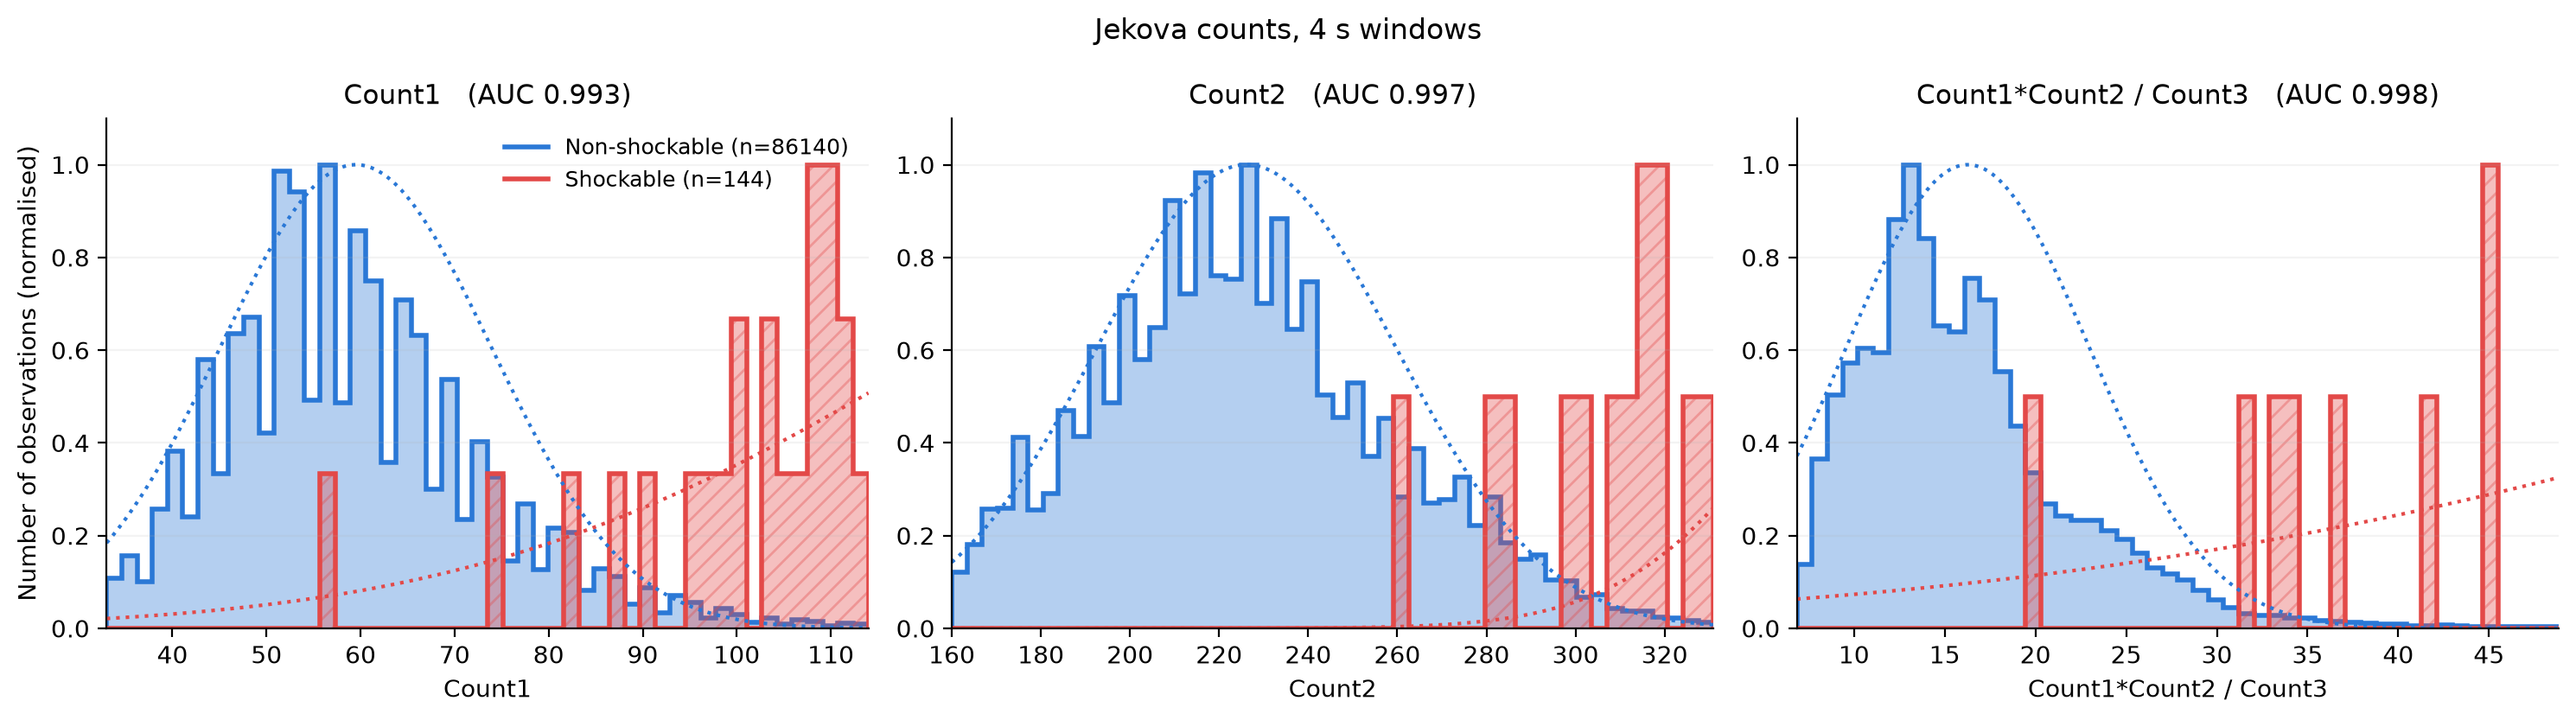

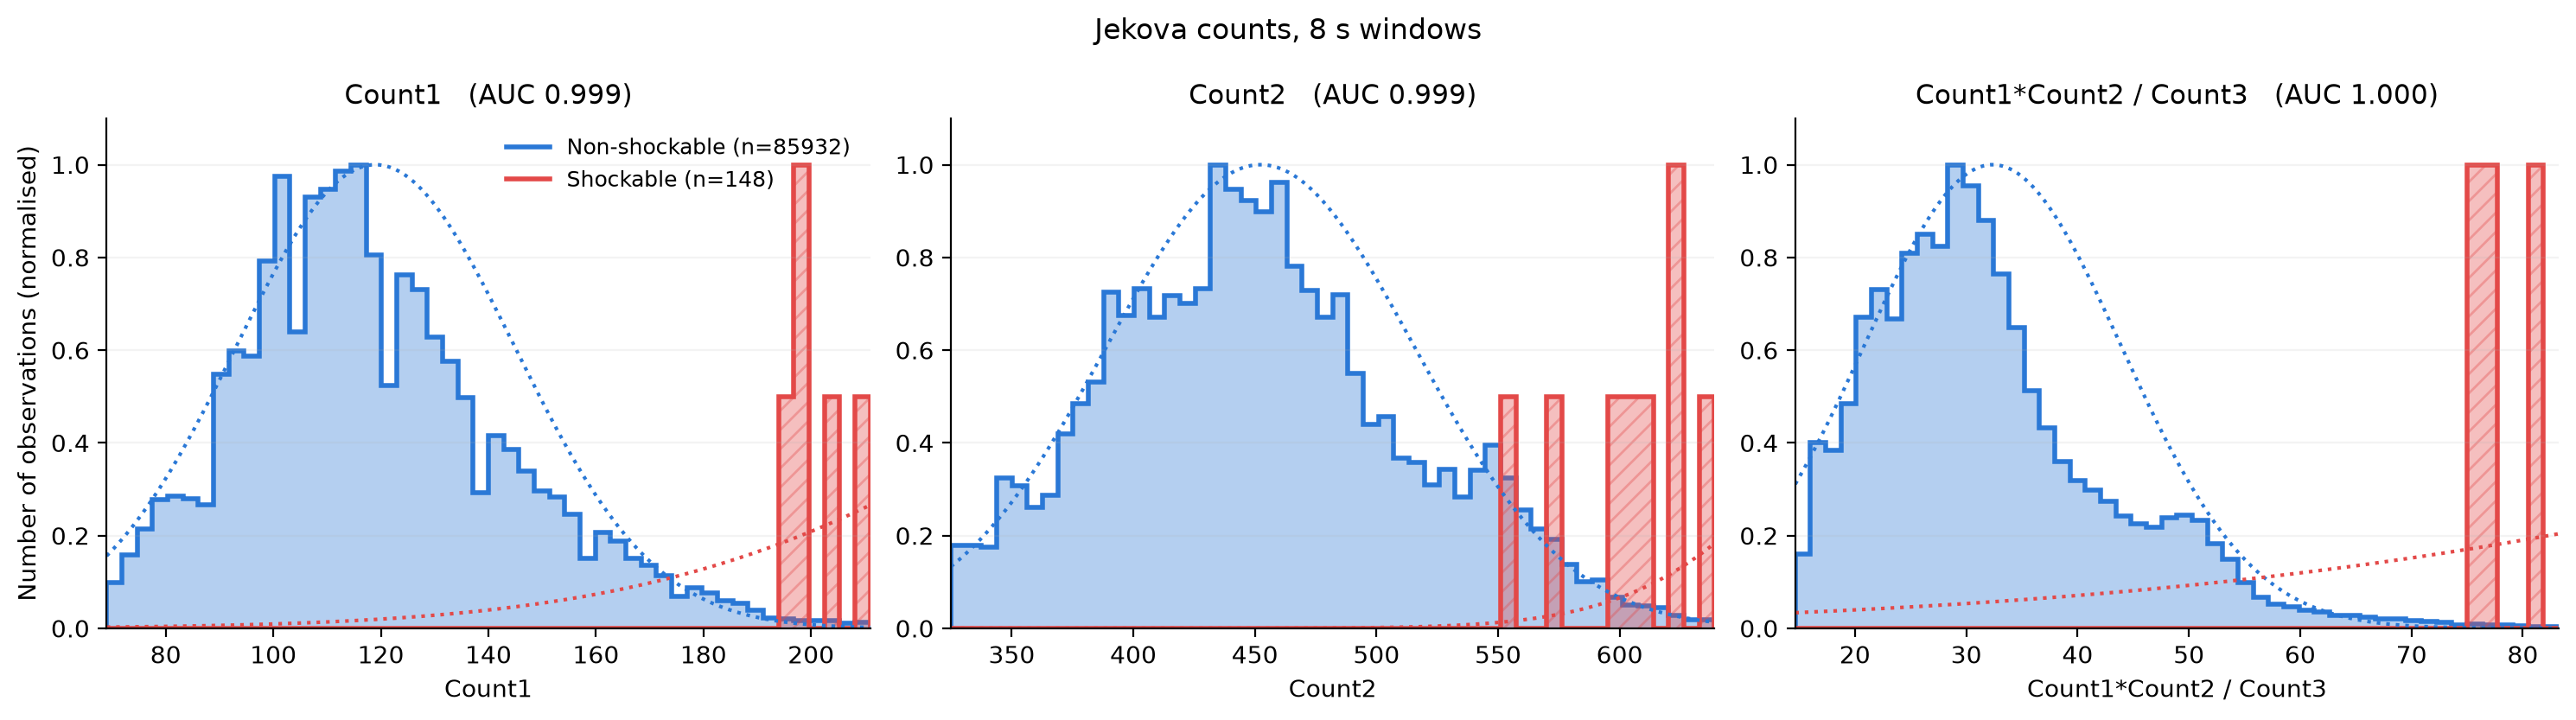

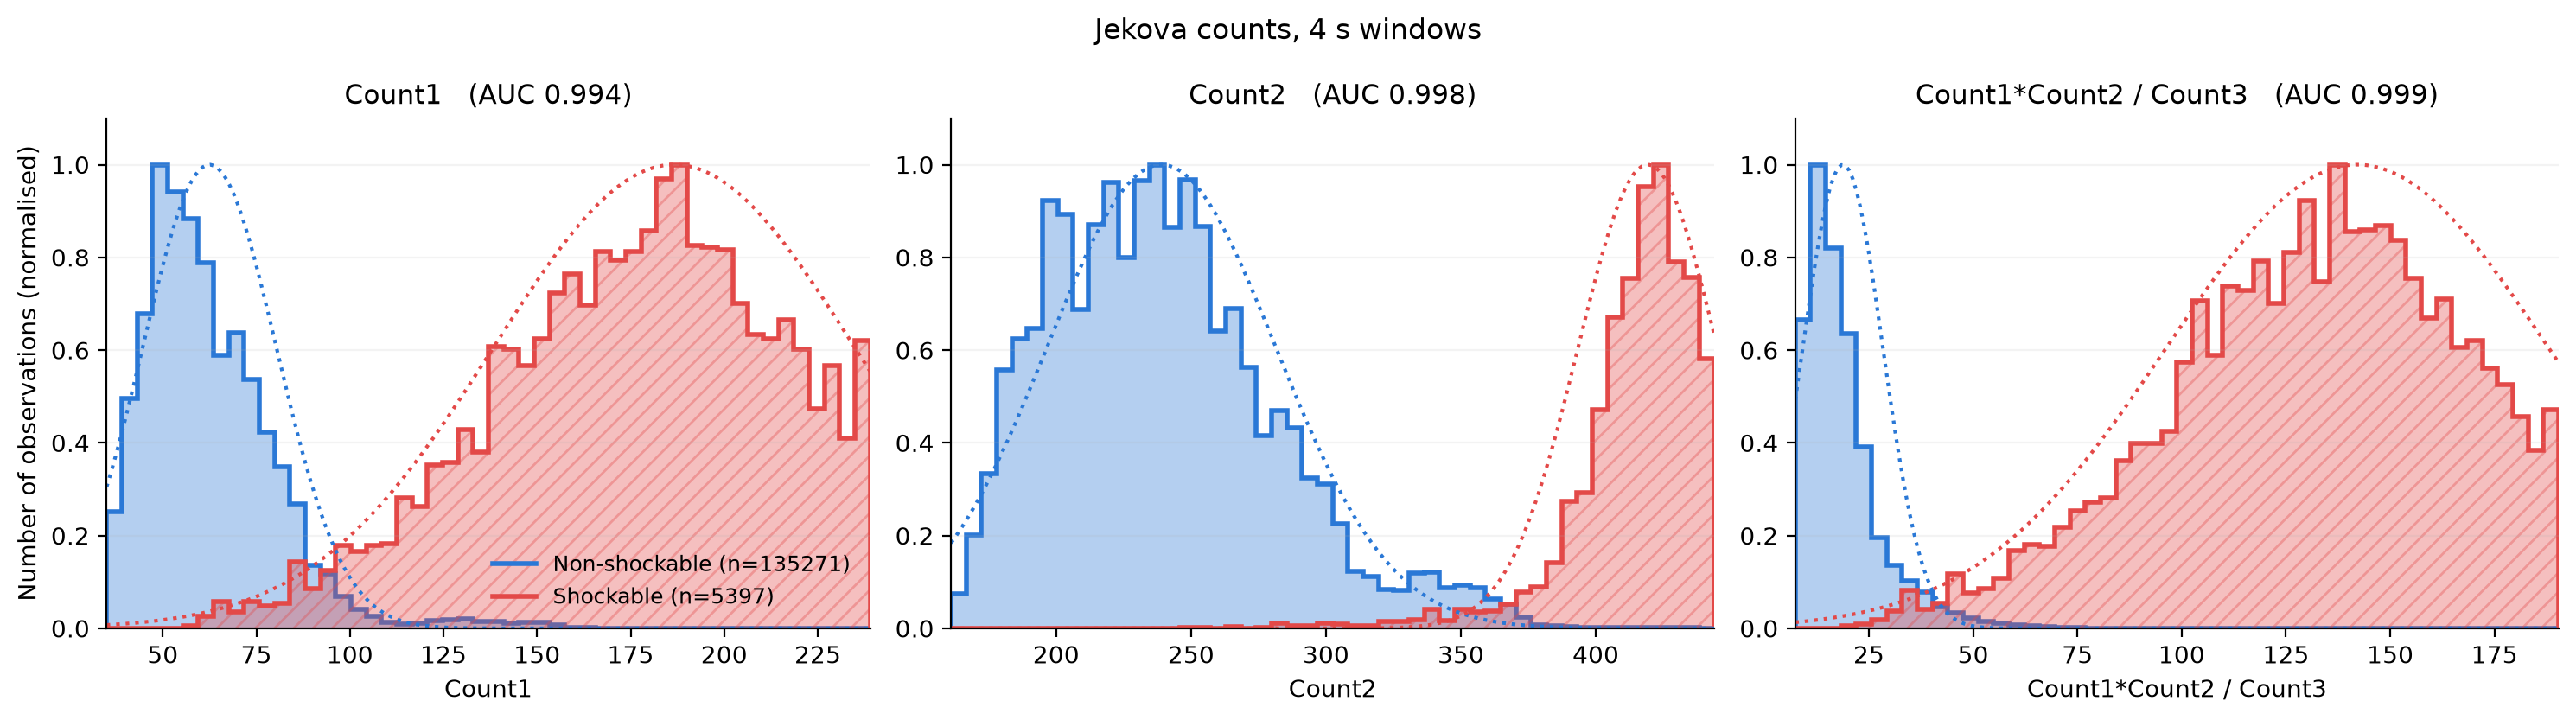

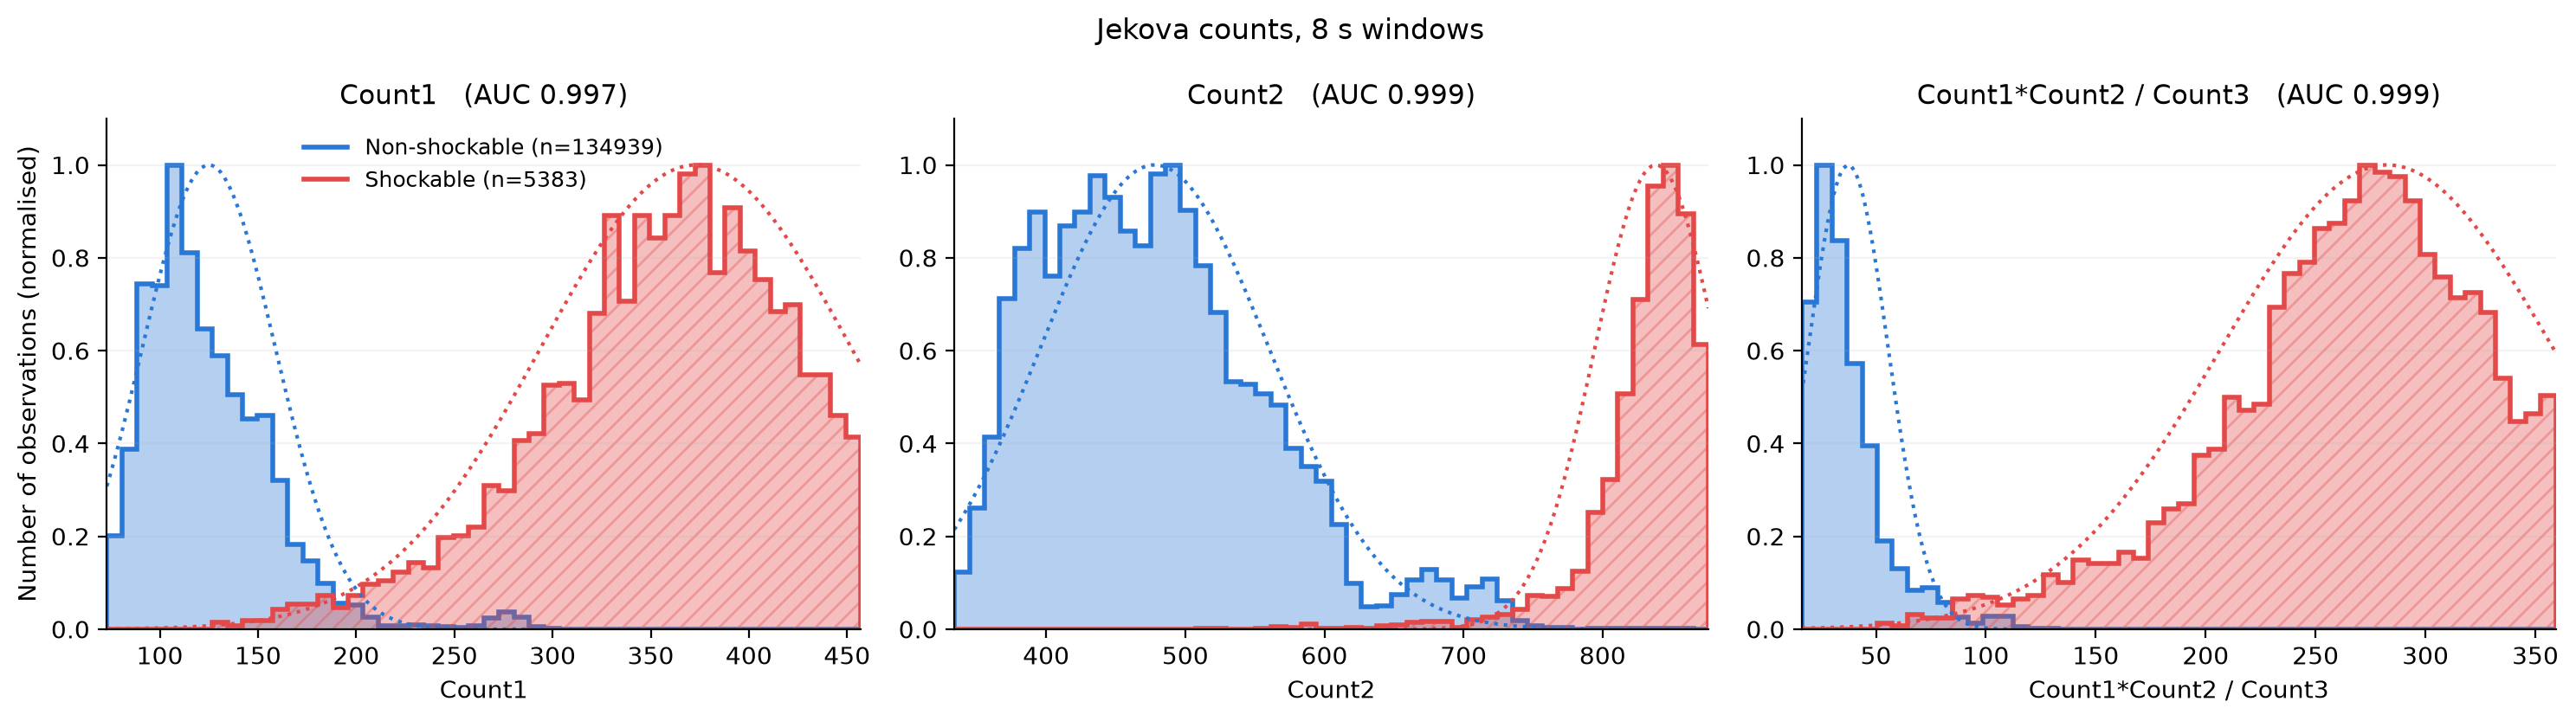

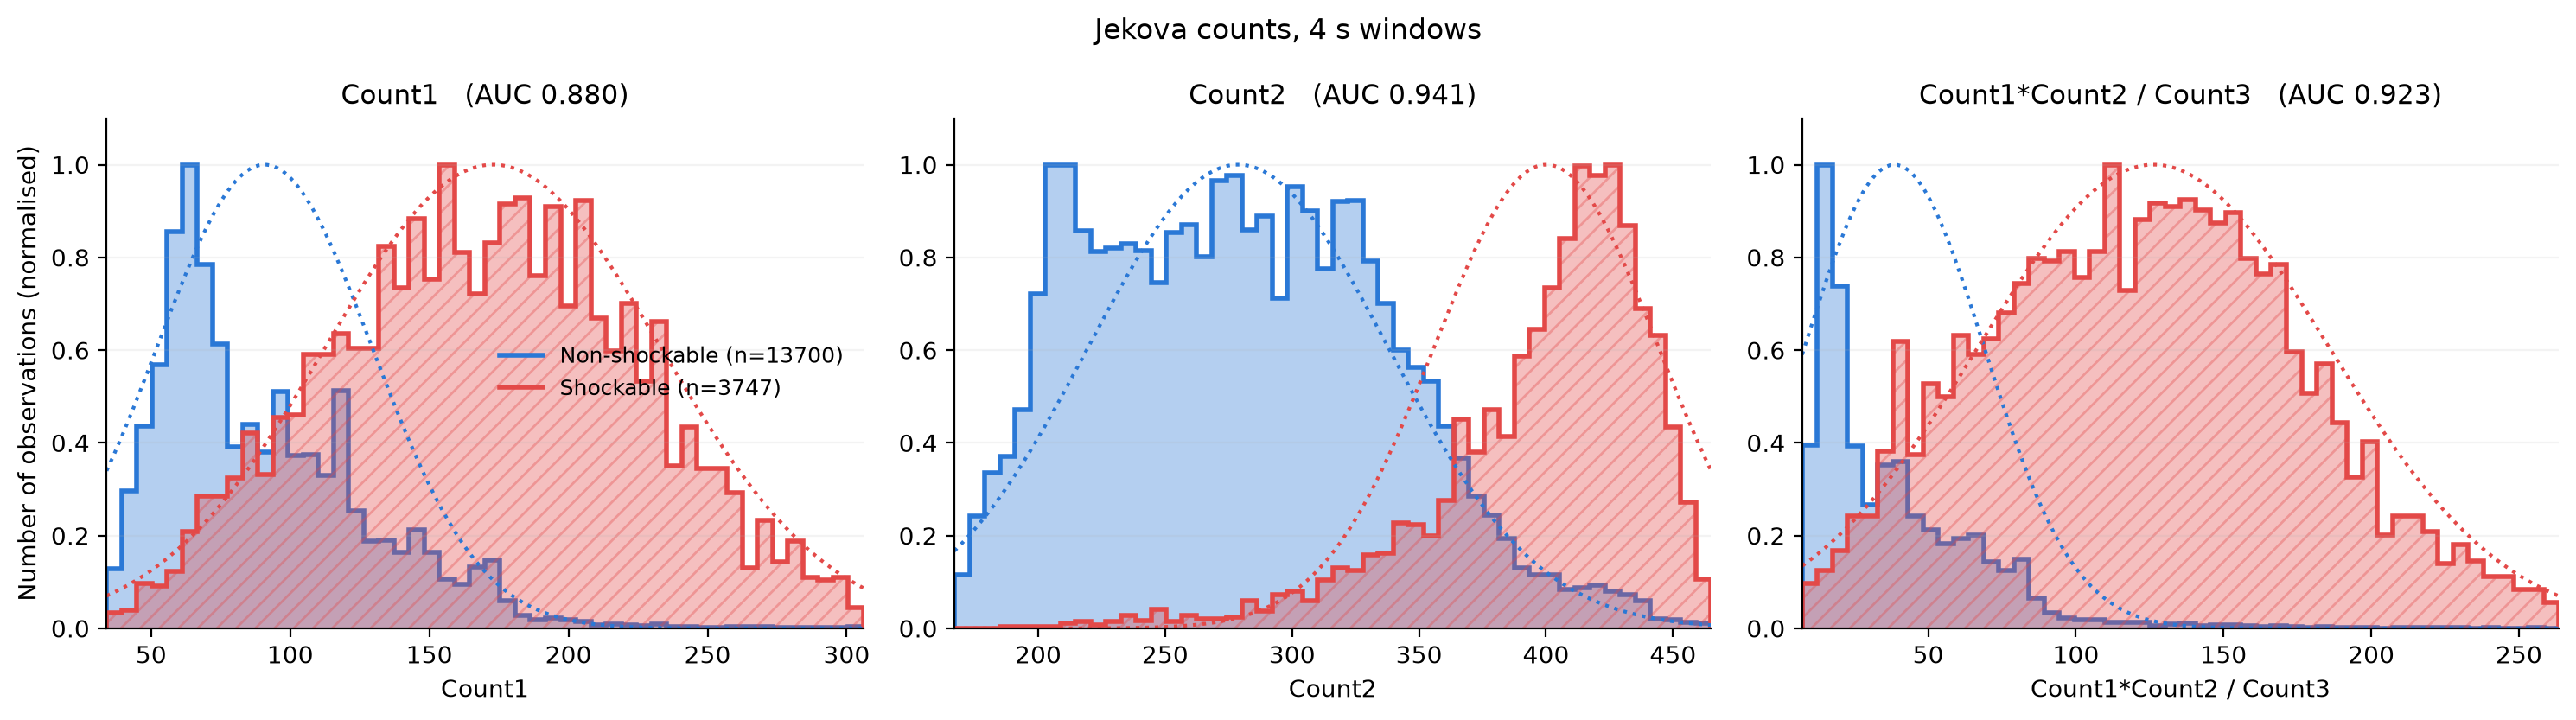

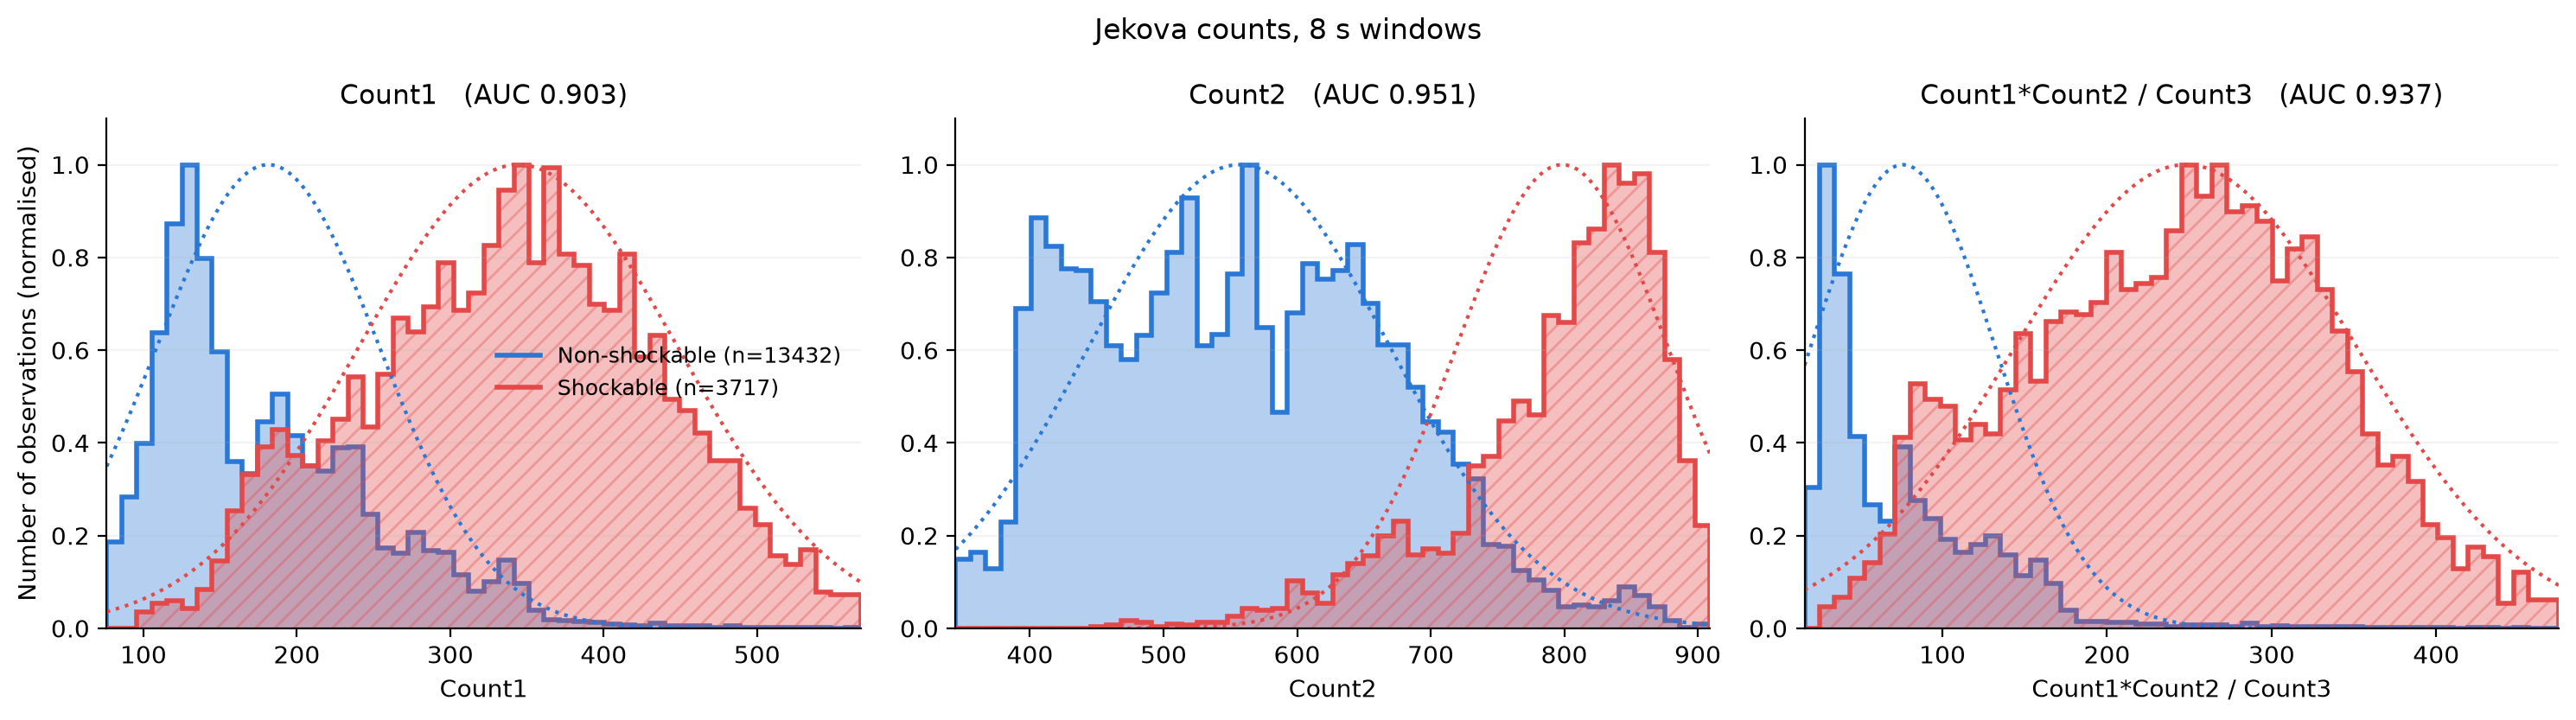

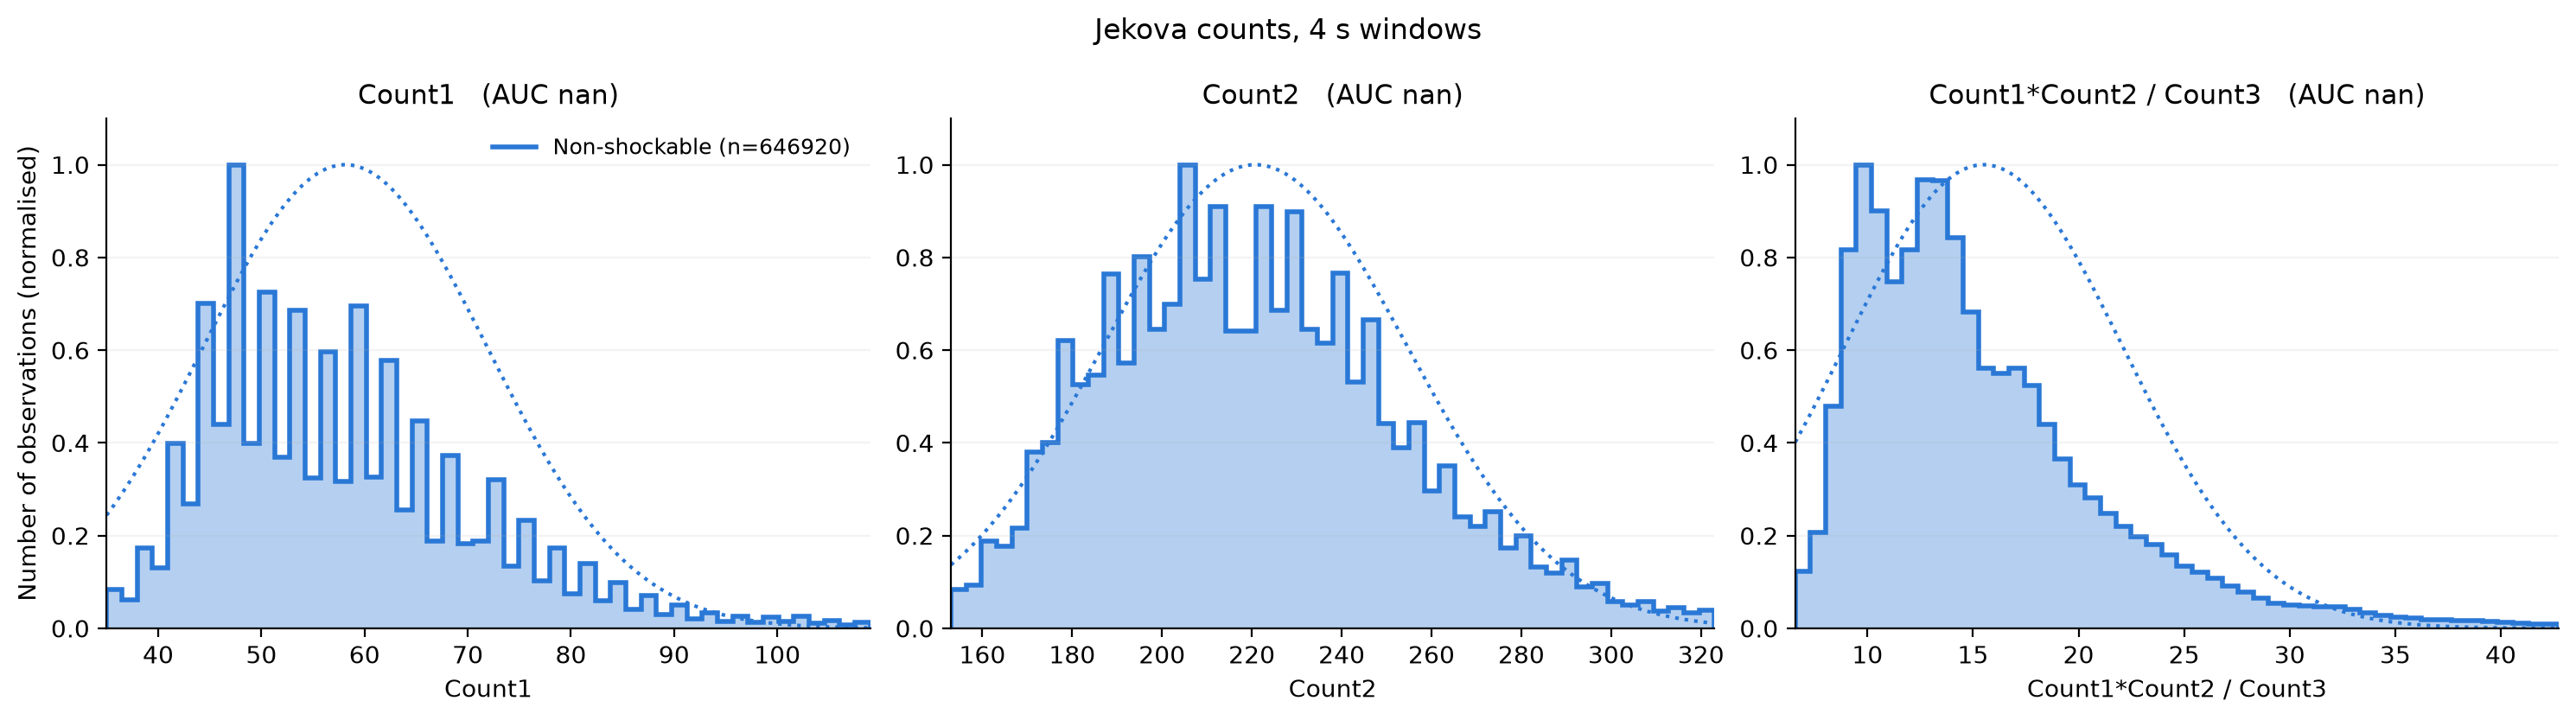

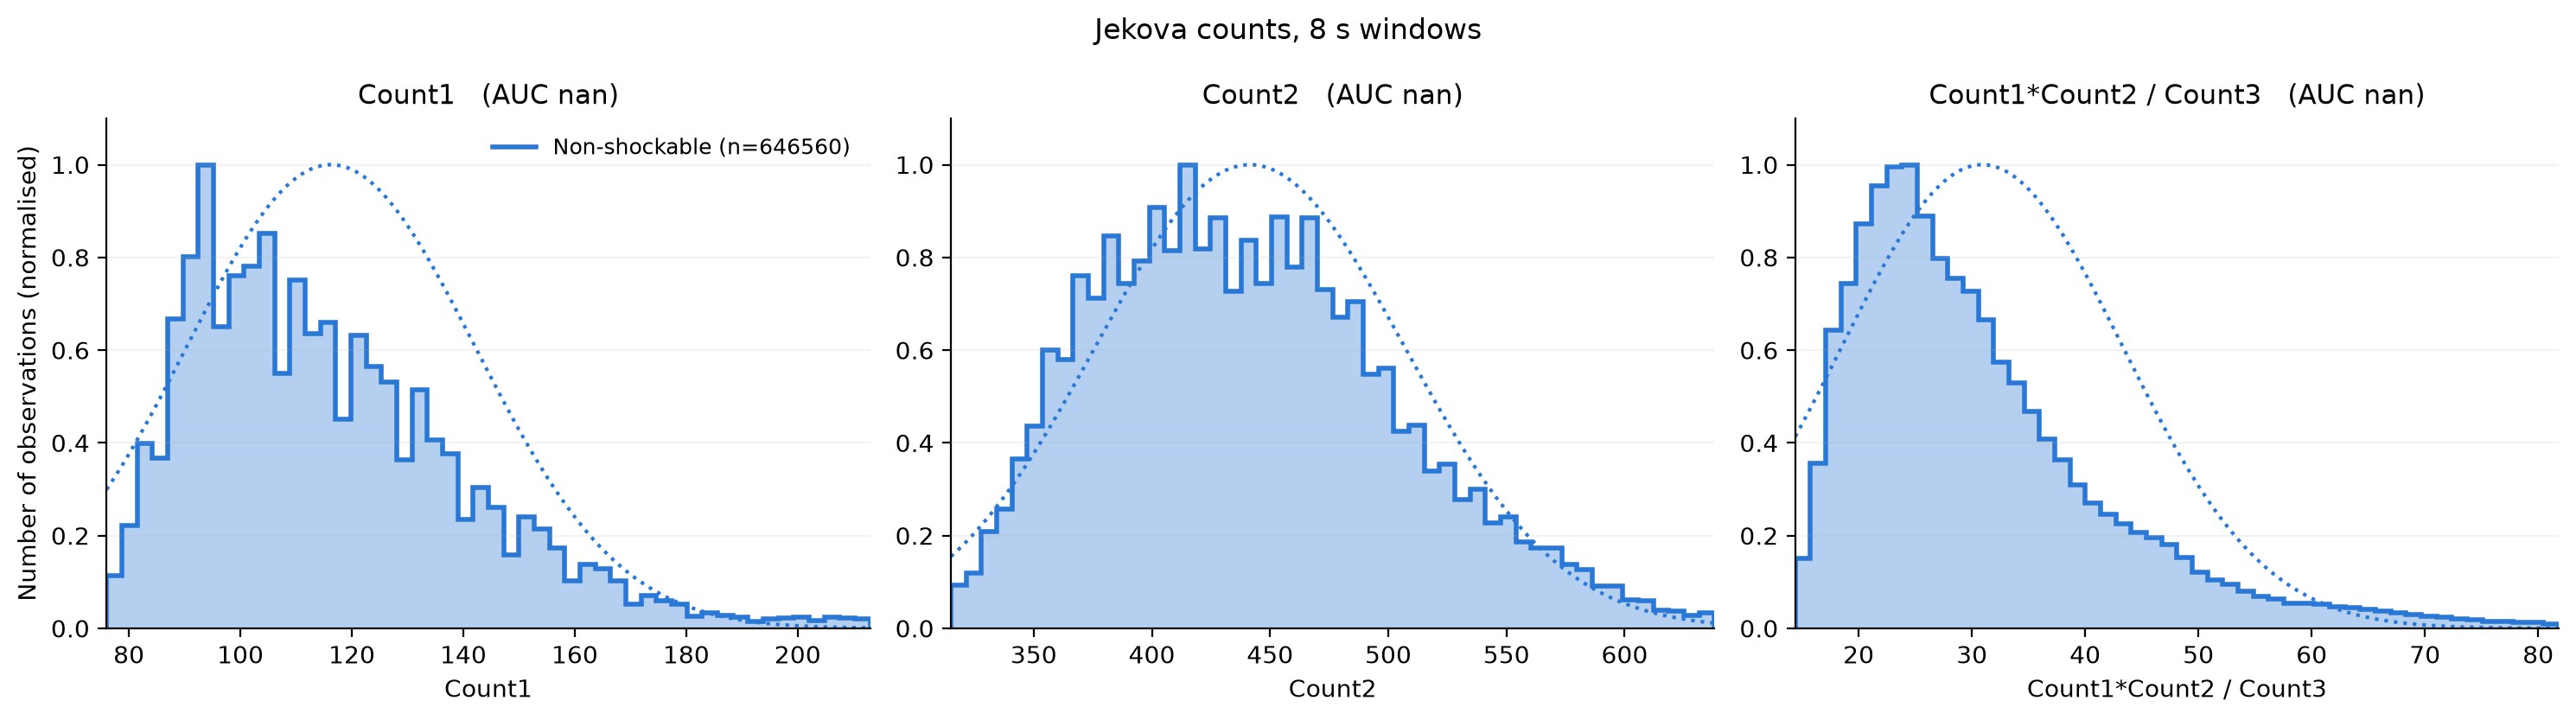

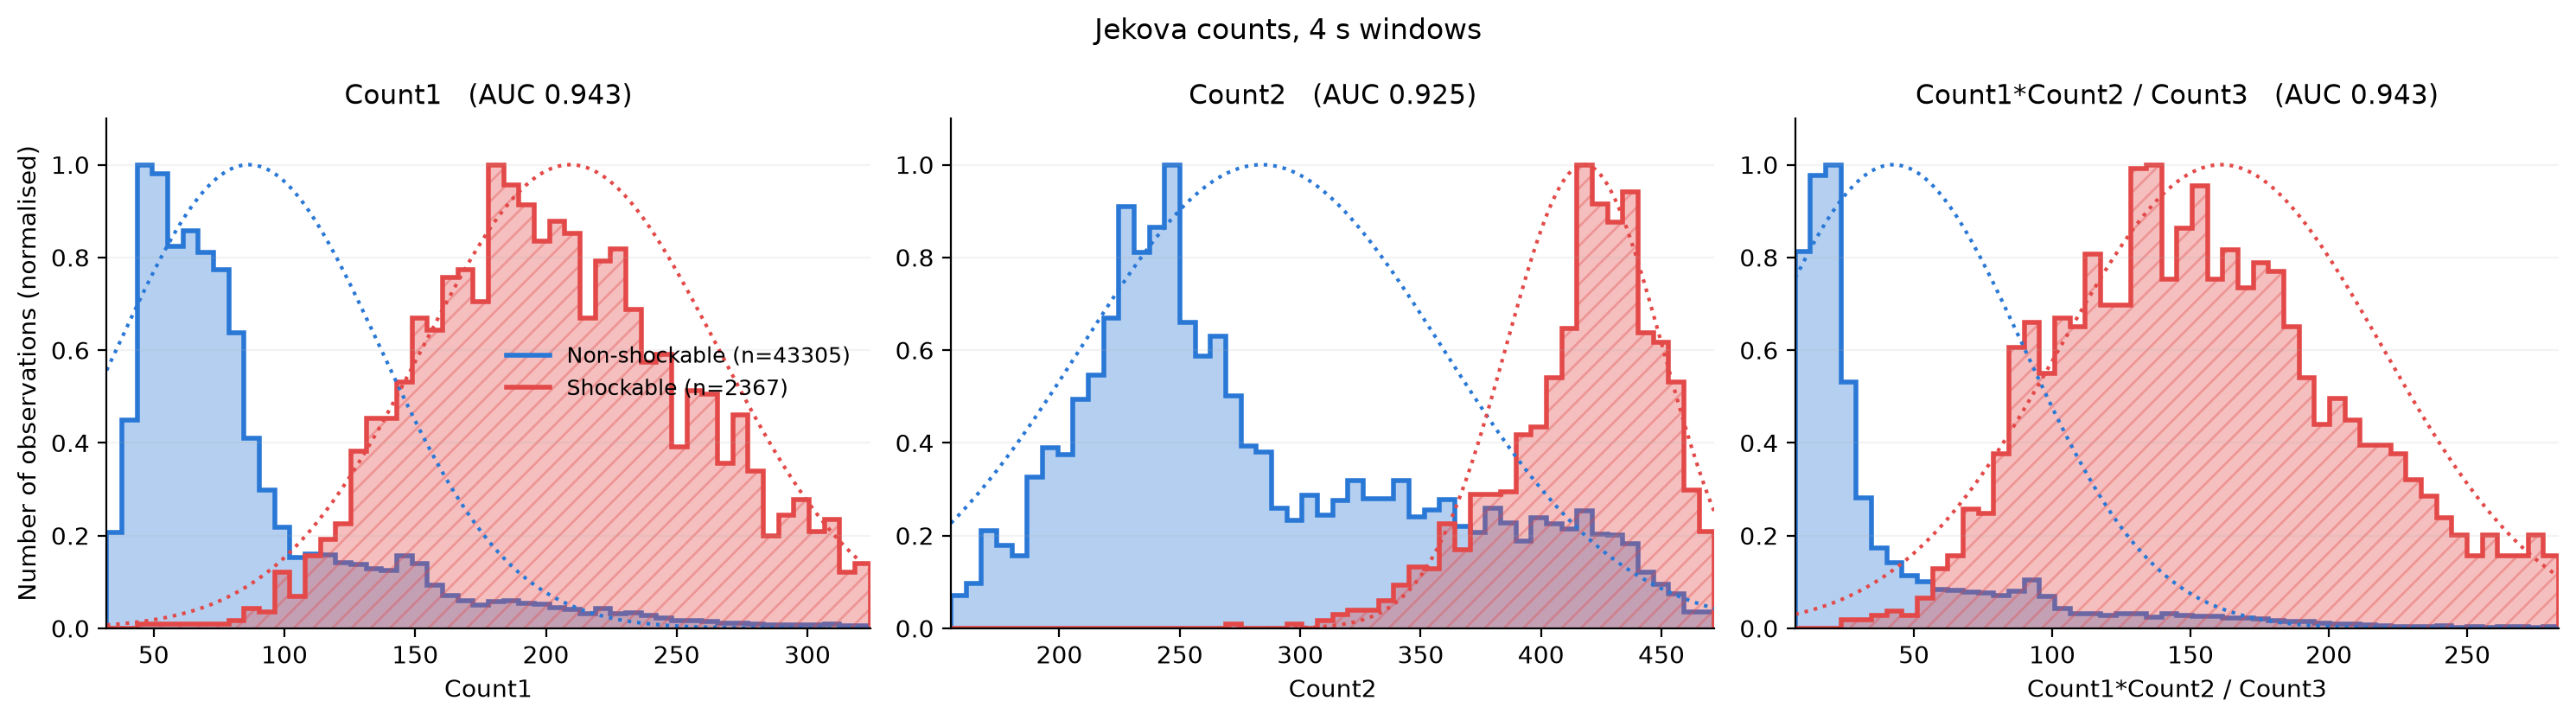

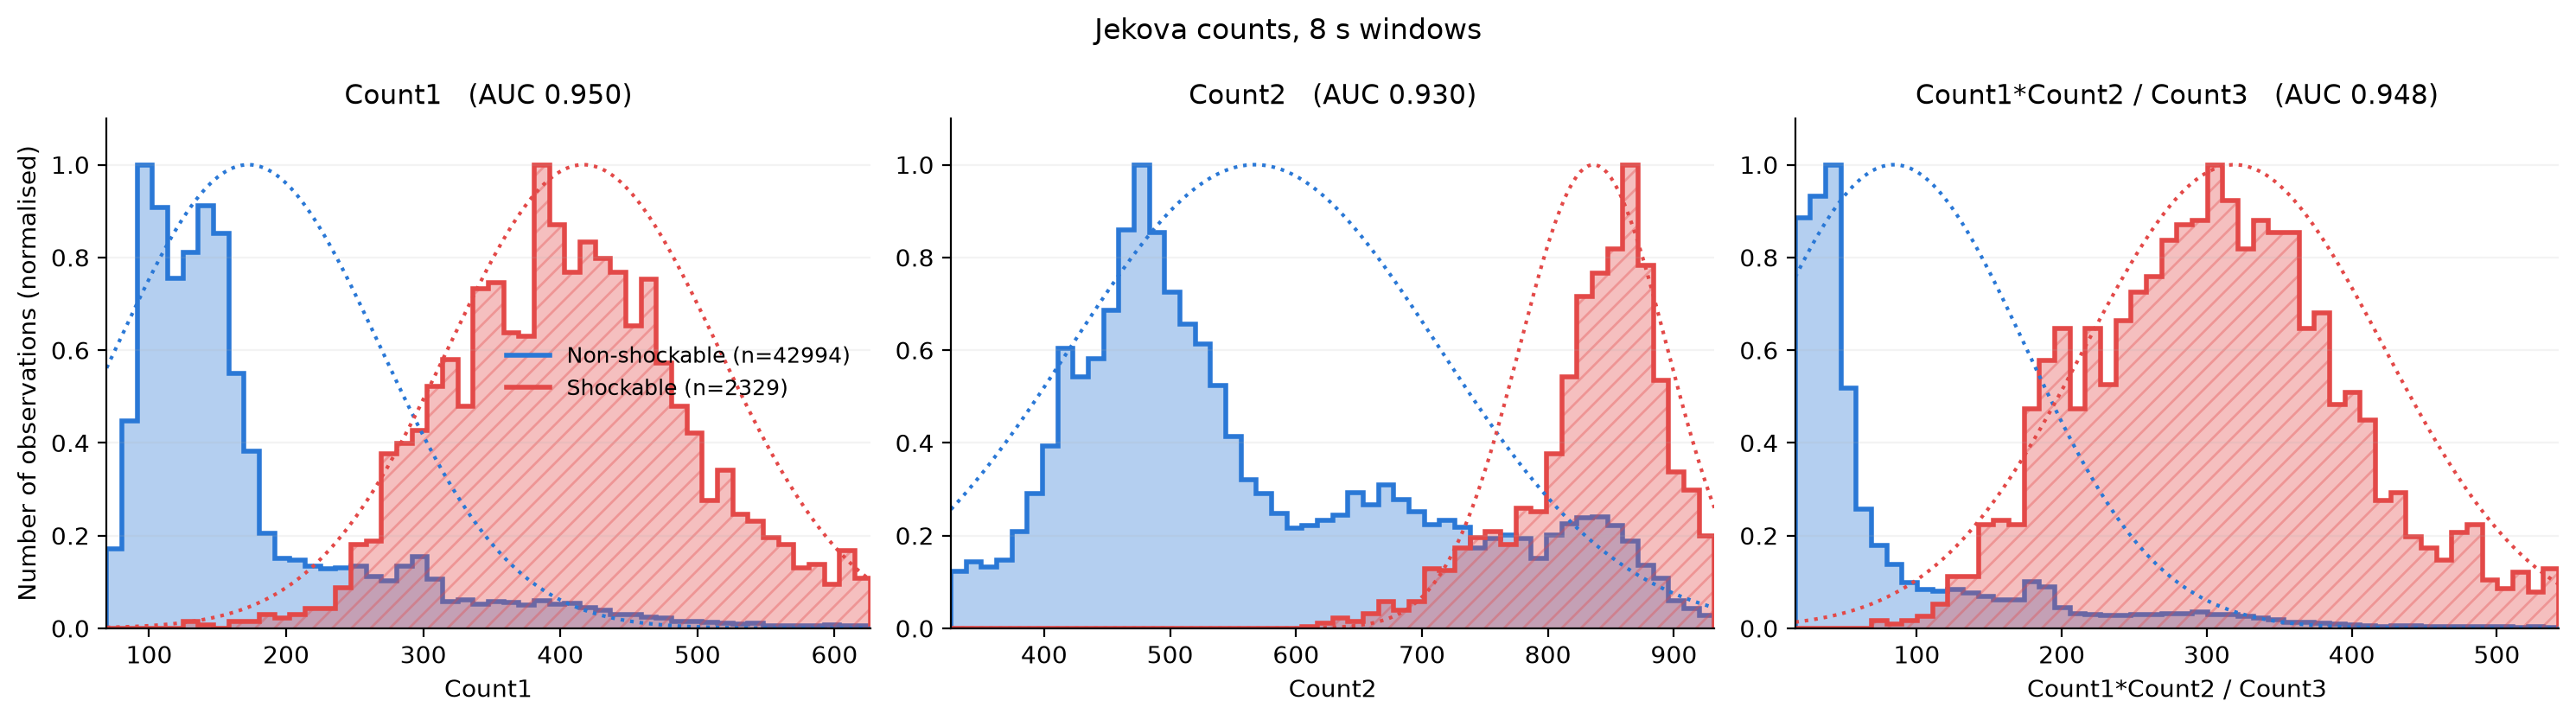

In [163]:
# EXG("mitdb", learn = True, cfm = True, devx = False, wrx = False)
# EXG("cudb", learn = True, cfm = True, devx = False, wrx = False)
# EXG("ahadb", learn = True, cfm = True, devx = False, wrx = False)
# EXG("edb", learn = True, cfm = True, devx = False, wrx = False)
# EXG("vfdb", learn = True, cfm = True, devx = False, wrx = False)

# PlotDatabase("mitdb")
# PlotDatabase("cudb")
# PlotDatabase("ahadb")

dfs, df4, df8 = ProcessDatabase("mitdb")
PlotHistograms(df4, title="Jekova counts, 4 s windows", xlim="clip")
PlotHistograms(df8, title="Jekova counts, 8 s windows", xlim="clip")
plt.show()

dfs, df4, df8 = ProcessDatabase("ahadb")
PlotHistograms(df4, title="Jekova counts, 4 s windows", xlim="clip")
PlotHistograms(df8, title="Jekova counts, 8 s windows", xlim="clip")
plt.show()

dfs, df4, df8 = ProcessDatabase("cudb")
PlotHistograms(df4, title="Jekova counts, 4 s windows", xlim="clip")
PlotHistograms(df8, title="Jekova counts, 8 s windows", xlim="clip")
plt.show()

dfs, df4, df8 = ProcessDatabase("edb")
PlotHistograms(df4, title="Jekova counts, 4 s windows", xlim="clip")
PlotHistograms(df8, title="Jekova counts, 8 s windows", xlim="clip")
plt.show()

dfs, df4, df8 = ProcessDatabase("vfdb")
PlotHistograms(df4, title="Jekova counts, 4 s windows", xlim="clip")
PlotHistograms(df8, title="Jekova counts, 8 s windows", xlim="clip")
plt.show()

In [ ]:
# Evaluate the published Jekova cascade, thresholds scaled to the window length.

EPOCH = 10 * FS          # the paper's 10 s epoch at 250 Hz = 2500 samples
FRAC = 0.85

def LoadDatabase(db: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Reload the per-second / 4 s / 8 s frames written by ProcessDatabase."""
    dfs = pd.read_csv(f"../work/vfib/{db}_dfs.tsv", sep="\t")
    df4 = pd.read_csv(f"../work/vfib/{db}_df4.tsv", sep="\t")
    df8 = pd.read_csv(f"../work/vfib/{db}_df8.tsv", sep="\t")
    return dfs, df4, df8
pass #def

# Published thresholds (paper section 2.2.5), valid for a 2500-sample epoch. Every
# count is a number of samples, so all of them scale linearly with the window
# length; the ratio Count1*Count2/Count3 scales linearly too, since N*N/N = N.
JEKOVA_THRESHOLDS = dict(C1_LO=250, C1_HI=400, C2_LO=600, C2_HI=950, C2_MAX=1100, RATIO=210)

def Thresholds(span: int, t: dict = JEKOVA_THRESHOLDS) -> dict:
    """Scale the published 10 s thresholds to a window of ``span`` samples."""
    k = span / EPOCH
    return {name: value * k for name, value in t.items()}
pass #def

def Classify(df: pd.DataFrame, t: dict = JEKOVA_THRESHOLDS) -> np.ndarray:
    """Jekova cascade -> 'S' shockable, 'N' non-shockable, '?' not classified."""
    span = int(df["pof"].iloc[0] - df["pon"].iloc[0])
    k = Thresholds(span, t)

    c1 = df["c1"].to_numpy(dtype=float)
    c2 = df["c2"].to_numpy(dtype=float)
    rr = Ratio(df)

    r1 = (c1 <  k["C1_LO"]) & (c2 > k["C2_HI"]) & (rr < k["RATIO"])
    r2 = (c1 >= k["C1_LO"]) & (c1 < k["C1_HI"]) & (c2 < k["C2_LO"]) & (rr < k["RATIO"])
    r3 = (c1 >= k["C1_LO"]) & (c2 > k["C2_HI"])
    r4 = (c2 >= k["C2_MAX"])

    out = np.full(len(df), "?", dtype="<U1")
    for rule, label in [(r1, "N"), (r2, "N"), (r3, "S"), (r4, "S")]:   # first match wins
        out = np.where((out == "?") & rule, label, out)
    pass #for
    return out
pass #def

def Evaluate(df: pd.DataFrame, frac: float = FRAC, t: dict = JEKOVA_THRESHOLDS) -> dict:
    """SEN / SPC of the cascade against the episode labels.

    'Not classified' counts as no-shock, which is the AED-safe reading: the paper
    sends those epochs to the step 8 wave-detection branch, which is not built here.
    """
    span = int(df["pof"].iloc[0] - df["pon"].iloc[0])
    call = Classify(df, t)

    # frac is a cut, not a band: every window lands in exactly one class, so
    # shock.sum() + nonsh.sum() == len(df)
    shock = (df["vfb"] >= frac * span).to_numpy()
    nonsh = ~shock
    # windows straddling an episode edge: some VF present, but under the cut.
    # nonsh / mixed / shock partition the windows; mixed is still SCORED as a
    # negative, it is only reported apart from the clear negatives
    mixed = (df["vfb"].to_numpy() > 0) & nonsh

    tp = int(((call == "S") & shock).sum())
    fn = int(((call != "S") & shock).sum())
    fp = int(((call == "S") & nonsh).sum())
    tn = int(((call != "S") & nonsh).sum())

    return dict(
        window       = f"{span // FS}s",
        nonsh        = int((nonsh & ~mixed).sum()),
        mixed        = int(mixed.sum()),
        shock        = int(shock.sum()),
        TP=tp, FN=fn, FP=fp, TN=tn,
        SPC          = round(100 * tn / (tn + fp), 2) if tn + fp else float("nan"),
        SEN          = round(100 * tp / (tp + fn), 2) if tp + fn else float("nan"),
        PPV          = round(100 * tp / (tp + fp), 2) if tp + fp else float("nan"),
        F1           = round(100 * 2 * tp / (2 * tp + fp + fn), 2) if 2 * tp + fp + fn else float("nan"),
    )
pass #def


print("MITDB")
dfs, df4, df8 = LoadDatabase("mitdb")
display(pd.DataFrame([Evaluate(df4), Evaluate(df8)]))

print("AHADB")
dfs, df4, df8 = LoadDatabase("ahadb")
display(pd.DataFrame([Evaluate(df4), Evaluate(df8)]))

print("CUDB")
dfs, df4, df8 = LoadDatabase("cudb")
display(pd.DataFrame([Evaluate(df4), Evaluate(df8)]))

print("EDB")
dfs, df4, df8 = LoadDatabase("edb")
display(pd.DataFrame([Evaluate(df4), Evaluate(df8)]))

print("VFDB")
dfs, df4, df8 = LoadDatabase("vfdb")
display(pd.DataFrame([Evaluate(df4), Evaluate(df8)]))

MITDB


,window,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,4s,86140,34,130,100,30,26,86148,99.97,76.92,79.37,78.12
1,8s,85932,62,118,102,16,2,85992,100.00,86.44,98.08,91.89


AHADB


,window,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,4s,135271,46,5382,5014,368,144,135173,99.89,93.16,97.21,95.14
1,8s,134939,92,5352,5090,262,117,134914,99.91,95.10,97.75,96.41


CUDB


,window,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,4s,13700,250,3655,2689,966,601,13349,95.69,73.57,81.73,77.44
1,8s,13432,503,3530,2699,831,553,13382,96.03,76.46,83.00,79.59


EDB


,window,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,4s,646920,0,0,0,0,92,646828,99.99,NaN,0.0,0.0
1,8s,646560,0,0,0,0,61,646499,99.99,NaN,0.0,0.0


VFDB


,window,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,4s,43305,586,2155,1969,186,6174,37717,85.93,91.37,24.18,38.24
1,8s,42994,912,2052,1931,121,6250,37656,85.77,94.10,23.60,37.74


In [191]:
# Threshold search: maximise the pooled F1 across all databases.

import itertools

DATABASES = ["mitdb", "ahadb", "cudb", "edb", "vfdb"]

# the published constants as fractions of the epoch, the unit the search works in
PUBLISHED = {k: v / EPOCH for k, v in JEKOVA_THRESHOLDS.items()}

def LoadAll(dbs: list[str] = DATABASES, which: str = "df8") -> pd.DataFrame:
    """Concatenate one window length across databases; missing files are skipped."""
    frames = []
    for db in dbs:
        try:
            frames.append(pd.read_csv(f"../work/vfib/{db}_{which}.tsv", sep="\t"))
        except FileNotFoundError:
            print(f"missing: {db}_{which}.tsv")
        pass #try
    pass #for
    return pd.concat(frames, ignore_index=True)
pass #def

def Fractions(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Counts as fractions of the window, so one threshold set fits every window length."""
    span = (df["pof"] - df["pon"]).to_numpy(dtype=float)
    c1 = df["c1"].to_numpy(dtype=float)
    c2 = df["c2"].to_numpy(dtype=float)
    c3 = df["c3"].to_numpy(dtype=float)
    return c1 / span, c2 / span, c1 * c2 / np.where(c3 > 0, c3, np.nan) / span
pass #def

def Decide(f1, f2, rr, t: dict) -> np.ndarray:
    """Cascade on fractions -> boolean shockable. 'Not classified' folds into no-shock."""
    r1 = (f1 <  t["C1_LO"]) & (f2 > t["C2_HI"]) & (rr < t["RATIO"])
    r2 = (f1 >= t["C1_LO"]) & (f1 < t["C1_HI"]) & (f2 < t["C2_LO"]) & (rr < t["RATIO"])
    r3 = (f1 >= t["C1_LO"]) & (f2 > t["C2_HI"])
    r4 = (f2 >= t["C2_MAX"])
    return (r3 | r4) & ~(r1 | r2)          # first match wins, R1/R2 before R3/R4
pass #def

SEARCH_GRID = dict(
    C1_LO  = [0.04, 0.06, 0.08, 0.10, 0.13, 0.16],
    C1_HI  = [0.16, 0.20, 0.26, 0.34],
    C2_LO  = [0.18, 0.24, 0.30],
    C2_HI  = [0.26, 0.32, 0.38, 0.44],
    C2_MAX = [0.40, 0.44, 0.50, 0.58],
    RATIO  = [0.05, 0.084, 0.15, 0.25],
)

def SearchThresholds(df: pd.DataFrame, frac: float = FRAC, grid: dict = SEARCH_GRID) -> pd.DataFrame:
    """One row per threshold combination.

    ``f1`` is the pooled F1: TP, FP and FN are summed across every database and
    the ratio taken once from the totals, so each window carries equal weight.
    The per-database mean/min Se and Sp ride along so the spread stays visible.
    """
    span = (df["pof"] - df["pon"]).to_numpy(dtype=float)
    y = (df["vfb"].to_numpy(dtype=float) >= frac * span)
    f1, f2, rr = Fractions(df)

    keys = list(grid)
    rows = []
    for combo in itertools.product(*(grid[k] for k in keys)):
        t = dict(zip(keys, combo))
        if t["C1_HI"] <= t["C1_LO"] or t["C2_MAX"] <= t["C2_HI"]:
            continue                       # keep the rules well formed
        pass #if
        pred = Decide(f1, f2, rr, t)

        # pooled confusion over every database, every metric taken from the totals
        tp = int((pred  &  y).sum()); fp = int((pred  & ~y).sum())
        fn = int((~pred &  y).sum()); tn = int((~pred & ~y).sum())
        sen = 100 * tp / (tp + fn) if tp + fn else np.nan
        spc = 100 * tn / (tn + fp) if tn + fp else np.nan
        rows.append({**t,
                     "F1":  round(100 * 2 * tp / (2 * tp + fp + fn), 2) if tp or fp or fn else 0.0,
                     "SEN": round(sen, 2),
                     "SPC": round(spc, 2),
                     "PPV": round(100 * tp / (tp + fp), 2) if tp + fp else np.nan,
                     "bacc": round((sen + spc) / 2, 2),
                     "TP": tp, "FP": fp, "FN": fn, "TN": tn})
    pass #for
    return pd.DataFrame(rows)
pass #def

def BestPoint(points: pd.DataFrame):
    """Highest pooled F1 over all databases."""
    pick = points.sort_values("F1", ascending=False).iloc[0]
    return {k: float(pick[k]) for k in SEARCH_GRID}, pick
pass #def

def Report(df: pd.DataFrame, t: dict, frac: float = FRAC) -> pd.DataFrame:
    """Per-database confusion counts and SPC / SEN / PPV / F1, plus a pooled TOTAL row."""
    span = (df["pof"] - df["pon"]).to_numpy(dtype=float)
    y = (df["vfb"].to_numpy(dtype=float) >= frac * span)
    pred = Decide(*Fractions(df), t)
    # windows straddling an episode edge: some VF present, but under the cut.
    # nonsh / mixed / shock partition the windows; mixed is still SCORED as a
    # negative, it is only reported apart from the clear negatives
    mix = (df["vfb"].to_numpy(dtype=float) > 0) & ~y

    out = []
    for db in df["db"].unique():
        m = (df["db"] == db).to_numpy()
        tp = int((pred[m] &  y[m]).sum()); fp = int((pred[m] & ~y[m]).sum())
        fn = int((~pred[m] & y[m]).sum()); tn = int((~pred[m] & ~y[m]).sum())
        out.append(dict(db=db,
                        nonsh=int((~y[m] & ~mix[m]).sum()),
                        mixed=int(mix[m].sum()),
                        shock=int(y[m].sum()),
                        TP=tp, FN=fn, FP=fp, TN=tn,
                        SPC=tn / (tn + fp) if tn + fp else np.nan,
                        SEN=tp / (tp + fn) if tp + fn else np.nan,
                        PPV=tp / (tp + fp) if tp + fp else np.nan,
                        F1=2 * tp / (2 * tp + fp + fn) if tp or fp or fn else np.nan))
    pass #for
    res = pd.DataFrame(out)

    # TOTAL pools the counts across databases and takes the ratios once, the same
    # quantity the threshold search maximises
    tp, fn = int(res["TP"].sum()), int(res["FN"].sum())
    fp, tn = int(res["FP"].sum()), int(res["TN"].sum())
    res.loc[len(res)] = dict(db="TOTAL",
                             nonsh=res["nonsh"].sum(), mixed=res["mixed"].sum(),
                             shock=res["shock"].sum(),
                             TP=tp, FN=fn, FP=fp, TN=tn,
                             SPC=tn / (tn + fp) if tn + fp else np.nan,
                             SEN=tp / (tp + fn) if tp + fn else np.nan,
                             PPV=tp / (tp + fp) if tp + fp else np.nan,
                             F1=2 * tp / (2 * tp + fp + fn) if tp or fp or fn else np.nan)

    # rates are reported as percentages with 2 decimals
    res[["SPC", "SEN", "PPV", "F1"]] = res[["SPC", "SEN", "PPV", "F1"]].mul(100).round(2)
    return res
pass #def


allx = LoadAll(which="df8")
display(Markdown("**Published thresholds**"))
display(Report(allx, PUBLISHED))

# thresholds are fitted on these databases only; every database is reported
SEARCH_DBS = ["mitdb", "ahadb", "cudb"]
fit = allx[allx["db"].isin(SEARCH_DBS)]

points = SearchThresholds(fit)
best, pick = BestPoint(points)
display(Markdown(f"**Searched** on {', '.join(SEARCH_DBS)} "
                 f"(pooled F1 {pick['F1']:.2f}, SEN {pick['SEN']:.2f}, SPC {pick['SPC']:.2f}): "
                 f"`{ {k: round(v, 3) for k, v in best.items()} }`"))
display(Report(allx, best))


**Published thresholds**

,db,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,mitdb,85932,62,118,102,16,2,85992,100.00,86.44,98.08,91.89
1,ahadb,134939,92,5352,5090,262,117,134914,99.91,95.10,97.75,96.41
2,cudb,13432,503,3530,2699,831,553,13382,96.03,76.46,83.00,79.59
3,edb,646560,0,0,0,0,61,646499,99.99,NaN,0.00,0.00
4,vfdb,42994,912,2052,1931,121,6250,37656,85.77,94.10,23.60,37.74
5,TOTAL,923857,1569,11052,9822,1230,6983,918443,99.25,88.87,58.45,70.52


**Searched** on mitdb, ahadb, cudb (pooled F1 89.86, SEN 87.68, SPC 99.71): `{'C1_LO': 0.1, 'C1_HI': 0.34, 'C2_LO': 0.24, 'C2_HI': 0.38, 'C2_MAX': 0.5, 'RATIO': 0.25}`

,db,nonsh,mixed,shock,TP,FN,FP,TN,SPC,SEN,PPV,F1
0,mitdb,85932,62,118,102,16,2,85992,100.00,86.44,98.08,91.89
1,ahadb,134939,92,5352,5090,262,117,134914,99.91,95.10,97.75,96.41
2,cudb,13432,503,3530,2699,831,553,13382,96.03,76.46,83.00,79.59
3,edb,646560,0,0,0,0,61,646499,99.99,NaN,0.00,0.00
4,vfdb,42994,912,2052,1931,121,6250,37656,85.77,94.10,23.60,37.74
5,TOTAL,923857,1569,11052,9822,1230,6983,918443,99.25,88.87,58.45,70.52
